# `campaign2_all.db` — data exploration

**Goal.** Understand what, *beyond the composition*, carries information about the
optimization `Objective`.

The compositions here are a ternary perovskite alloy — `FAPbI3 + MAPbI3 + MAPbBr3 = 1`
(verified below) — so "knowing the composition" fixes 2 continuous degrees of freedom.
The central question is therefore a **conditional** one:

> Given that we already know the composition, how much *additional* information does
> each other measured feature carry about the `Objective`?

This is conditional mutual information, $I(\text{Objective};\,F \mid \text{composition})$.

**Plan**
1. Load, clean, and group the 674 columns.
2. Overview: the composition simplex, the objective, and the (large) missing-data structure.
3. **Part A** — CMI of the objective vs. each *scalar* feature, given composition (kNN / KSG estimator).
4. **Part B** — collapse each large *functional* feature group (absorption spectrum, stability
   voltage sweep, PL spectra) to a handful of **functional-PCA** scores.
5. **Part C** — CMI of the objective vs. those fPCA scores, and a combined ranking.

> **Caveat up front.** `Objective` is (by construction) a deterministic combination of
> `Bandgap`, `Photoconductance` and `Stability`. Those three will therefore score highly
> for reasons of *definition*, not discovery — we keep them in, but flag them. The
> interesting signal is in everything *else*.

## 1&nbsp;&middot;&nbsp;Setup, load & column grouping

In [38]:
import sqlite3, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import digamma
from scipy.spatial import cKDTree

from skfda import FDataGrid
from skfda.representation.basis import BSplineBasis
from skfda.preprocessing.dim_reduction import FPCA

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
rng = np.random.default_rng(0)
DB = "data/campaign2_all.db"

df = pd.read_sql("select * from results", sqlite3.connect(DB))

# wall-clock time as seconds since the campaign start (Timestamp is stored as text)
_t = pd.to_datetime(df["Timestamp"])
df["_time_sec"] = (_t - _t.min()).dt.total_seconds()
print("raw shape:", df.shape)
print(f"campaign spans {df['_time_sec'].max()/3600:.1f} h; "
      f"time_sec vs Iteration Spearman = "
      f"{df[['_time_sec','Iteration']].corr('spearman').iloc[0,1]:.3f}")

raw shape: (953, 675)
campaign spans 54.3 h; time_sec vs Iteration Spearman = 1.000


In [39]:
# ---- classify the 674 columns into groups -----------------------------------
def _isnum(s):
    try:
        float(s); return True
    except ValueError:
        return False

COMP   = ["FAPbI3", "MAPbI3", "MAPbBr3"]                 # ternary composition (sums to 1)
TARGETS = ["Objective", "Bandgap", "Photoconductance", "Stability"]
ENV    = ["Temperature_in", "Temperature_out", "Humidity_in", "Humidity_out",
          "Pressure_in", "Pressure_out", "DMF_ppm_in", "DMF_ppm_out"]
KIN    = ["k1", "k2", "k3", "k1_var", "k2_var", "k3_var"]

ABSORP = [c for c in df.columns if _isnum(c)]                     # 462 absorption wavelengths
STAB   = [c for c in df.columns if re.match(r"^-?\d+_(dark|light)_\d+$", c)]  # 120 sweep cols
IPL    = [c for c in df.columns if c.endswith("_i_pl")]          # 30 initial-PL wavelengths
FPL    = [c for c in df.columns if c.endswith("_f_pl")]          # 30 final-PL wavelengths
MODULES = [c for c in df.columns if re.match(r"^Module\d$", c)]  # all-zero, dropped below

# Module1..7 are identically zero in this campaign -> carry no information
assert (df[MODULES] == 0).all().all(), "Modules unexpectedly non-zero"
df = df.drop(columns=MODULES)

groups = {"composition": COMP, "targets": TARGETS, "environment": ENV,
          "kinetics": KIN, "absorption": ABSORP, "stability_sweep": STAB,
          "PL_initial": IPL, "PL_final": FPL}
for g, cols in groups.items():
    print(f"{g:16} {len(cols):4d} cols   (dropped {len(MODULES)} all-zero Module cols)"
          if g == "composition" else f"{g:16} {len(cols):4d} cols")

composition         3 cols   (dropped 7 all-zero Module cols)
targets             4 cols
environment         8 cols
kinetics            6 cols
absorption        462 cols
stability_sweep   120 cols
PL_initial         30 cols
PL_final           30 cols


## 2&nbsp;&middot;&nbsp;Overview: composition simplex, objective & missingness

In [40]:
# The three composition fractions sum to 1 -> a 2-simplex (2 real DOF).
comp_sum = df[COMP].sum(axis=1)
print(f"FAPbI3+MAPbI3+MAPbBr3:  min={comp_sum.min():.6f}  max={comp_sum.max():.6f}  "
      f"(constant 1 => ternary simplex, 2 DOF)")
print(f"unique composition rows: {df[COMP].drop_duplicates().shape[0]} / {len(df)}  "
      f"=> effectively continuous, not discrete groups")

# Missingness per group (only some spots get the full evaluation)
miss = {g: 100 * df[cols].isna().any(axis=1).mean() for g, cols in groups.items()}
print("\n% of rows with >=1 NaN, by group:")
for g, v in miss.items():
    print(f"  {g:16} {v:5.1f}%")

FAPbI3+MAPbI3+MAPbBr3:  min=1.000000  max=1.000000  (constant 1 => ternary simplex, 2 DOF)
unique composition rows: 937 / 953  => effectively continuous, not discrete groups

% of rows with >=1 NaN, by group:
  composition        0.0%
  targets           32.4%
  environment        0.0%
  kinetics          74.1%
  absorption         0.0%
  stability_sweep   10.3%
  PL_initial        74.1%
  PL_final          74.1%


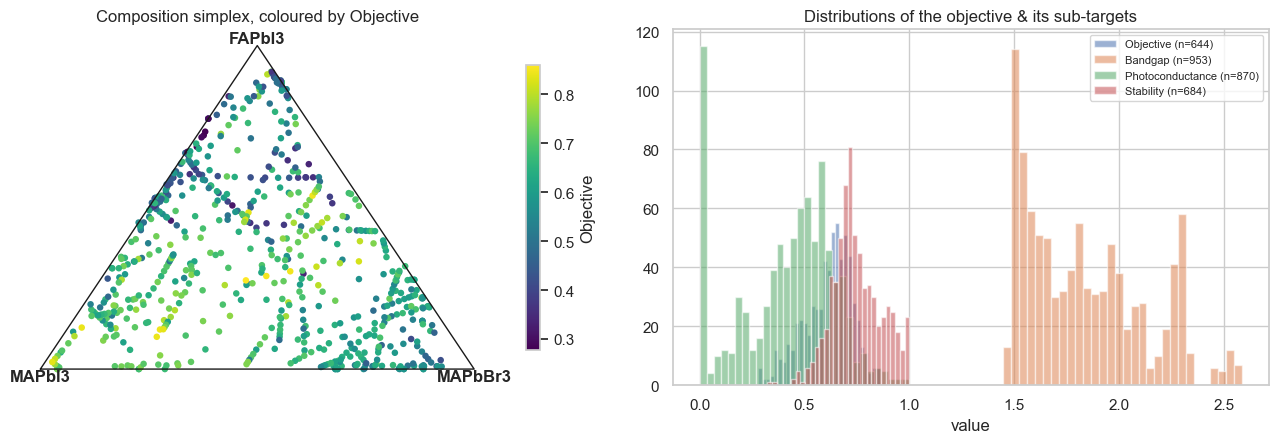

In [41]:
# Ternary scatter (FAPbI3, MAPbI3, MAPbBr3) coloured by Objective
def ternary_xy(a, b, c):
    # a=top, b=bottom-left, c=bottom-right
    return 0.5 * (2 * c + a) / (a + b + c), (np.sqrt(3) / 2) * a / (a + b + c)

d_obj = df[df["Objective"].notna()]
x, y = ternary_xy(d_obj["FAPbI3"].values, d_obj["MAPbI3"].values, d_obj["MAPbBr3"].values)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
sc = axes[0].scatter(x, y, c=d_obj["Objective"], cmap="viridis", s=22, edgecolor="none")
for (px, py, lbl) in [(0.5, np.sqrt(3)/2, "FAPbI3"), (0, 0, "MAPbI3"), (1, 0, "MAPbBr3")]:
    axes[0].annotate(lbl, (px, py), ha="center",
                     va="bottom" if py > 0 else "top", fontweight="bold")
axes[0].plot([0, 1, 0.5, 0], [0, 0, np.sqrt(3)/2, 0], color="k", lw=1)
axes[0].set_title("Composition simplex, coloured by Objective"); axes[0].axis("off")
fig.colorbar(sc, ax=axes[0], label="Objective", shrink=0.8)

for t in TARGETS:
    axes[1].hist(df[t].dropna(), bins=30, alpha=0.55, label=f"{t} (n={df[t].notna().sum()})")
axes[1].set_title("Distributions of the objective & its sub-targets")
axes[1].set_xlabel("value"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

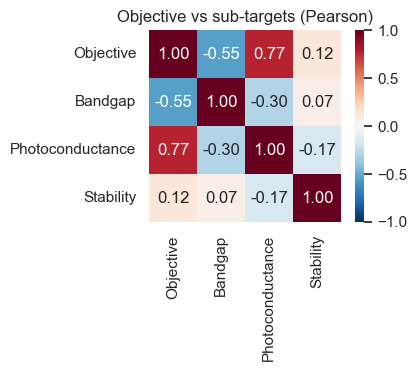

In [42]:
# How the sub-targets relate to the Objective (Pearson) -- expect strong ties by construction
corr = df[TARGETS].corr()
plt.figure(figsize=(4.6, 3.8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True)
plt.title("Objective vs sub-targets (Pearson)"); plt.tight_layout(); plt.show()

## 3&nbsp;&middot;&nbsp;Conditional mutual information estimator

Composition is *continuous*, so we can't just bin it. We use the
**Frenzel–Pompe / KSG** k-nearest-neighbour estimator of conditional mutual information
(Frenzel & Pompe, *PRL* 2007) — the conditional extension of Kraskov–Stögbauer–Grassberger:

$$\hat I(X;Y\mid Z)=\psi(k)+\Big\langle\,\psi(n_z+1)-\psi(n_{xz}+1)-\psi(n_{yz}+1)\,\big\rangle$$

For each point we take the distance $\varepsilon$ to its $k$-th neighbour in the joint
$(X,Y,Z)$ space (Chebyshev norm), then count neighbours within $\varepsilon$ in the
$(X,Z)$, $(Y,Z)$ and $Z$ marginal subspaces. Values are in **nats**; $0$ means
conditional independence. We also provide a **permutation test** (shuffle $X$ within
neighbourhoods of $Z$) to get a null distribution and a $p$-value.

We condition on **two** sets and compare them, because composition alone is not enough:

- $Z_\text{comp}=(\text{FAPbI3},\text{MAPbBr3})$ — 2 independent simplex coordinates
  (`MAPbI3` is redundant given the sum-to-one constraint).
- $Z_\text{full}=(\text{FAPbI3},\text{MAPbBr3},\,t,\,\text{Iteration})$ — composition **plus wall-clock
  time and BO iteration**.

**Why the extra conditioning matters.** Over the 2.3-day campaign the glovebox state drifts
(e.g. `Humidity_out` vs iteration $\rho=-0.68$) while the optimizer steadily improves the
objective ($\rho=+0.19$). That makes the environment channels *spuriously* informative about the
objective through a shared time trend. Conditioning on time + iteration removes that path, so
the difference $\hat I(\cdot\mid Z_\text{comp})-\hat I(\cdot\mid Z_\text{full})$ **is the size of
the temporal confound**. A feature whose CMI survives $Z_\text{full}$ carries information that is
not just campaign drift.

In [43]:
def _as_col(a):
    a = np.asarray(a, float)
    return a.reshape(-1, 1) if a.ndim == 1 else a

def _standardize(a):
    s = a.std(0); s[s == 0] = 1.0
    return (a - a.mean(0)) / s

def cmi_ksg(X, Y, Z, k=5):
    """KSG/Frenzel-Pompe estimate of I(X;Y|Z) in nats (>=0)."""
    X, Y, Z = _standardize(_as_col(X)), _standardize(_as_col(Y)), _standardize(_as_col(Z))
    n = len(X)
    XYZ = np.hstack([X, Y, Z]); XZ = np.hstack([X, Z]); YZ = np.hstack([Y, Z])
    eps = cKDTree(XYZ).query(XYZ, k=k + 1, p=np.inf)[0][:, -1]
    def _count(A):
        t = cKDTree(A)
        return np.fromiter((len(t.query_ball_point(A[i], eps[i] - 1e-12, p=np.inf)) - 1
                            for i in range(n)), dtype=float, count=n)
    val = digamma(k) + np.mean(digamma(_count(Z) + 1)
                               - digamma(_count(XZ) + 1) - digamma(_count(YZ) + 1))
    return max(float(val), 0.0)

def cmi_pvalue(X, Y, Z, k=5, n_perm=100, seed=0):
    """Permutation p-value: shuffle X among Z-neighbours to preserve I(X;Z), break I(X;Y|Z)."""
    X, Y, Z = _as_col(X), _as_col(Y), _as_col(Z)
    obs = cmi_ksg(X, Y, Z, k)
    r = np.random.default_rng(seed)
    # local permutation: restricted shuffle within nearest-neighbour blocks in Z
    nbrs = cKDTree(_standardize(Z)).query(_standardize(Z), k=min(10, len(X)))[1]
    null = np.empty(n_perm)
    for p in range(n_perm):
        perm = np.arange(len(X))
        order = r.permutation(len(X))
        for i in order:                              # swap i with a random Z-neighbour
            j = nbrs[i, r.integers(nbrs.shape[1])]
            perm[i], perm[j] = perm[j], perm[i]
        null[p] = cmi_ksg(X[perm], Y, Z, k)
    return obs, (1 + np.sum(null >= obs)) / (1 + n_perm)

def clean_xyz(x, obj, Z):
    """Align a feature/objective/composition triple on finite rows."""
    x = np.asarray(x, float)
    m = np.isfinite(x) & np.isfinite(obj) & np.isfinite(Z).all(1)
    return x[m], obj[m], Z[m], int(m.sum())

# objective + the two conditioning sets, reused throughout
OBJ       = df["Objective"].values
COND_COMP = df[["FAPbI3", "MAPbBr3"]].values                          # composition only
COND_FULL = df[["FAPbI3", "MAPbBr3", "_time_sec", "Iteration"]].values  # + time + iteration

def cmi_both(feat_values, k=5):
    """Return (CMI | composition, CMI | composition+time+iteration, n) on shared finite rows."""
    x = np.asarray(feat_values, float)
    m = np.isfinite(x) & np.isfinite(OBJ) & np.isfinite(COND_FULL).all(1)
    if m.sum() < 50:
        return np.nan, np.nan, int(m.sum())
    return (cmi_ksg(x[m], OBJ[m], COND_COMP[m], k),
            cmi_ksg(x[m], OBJ[m], COND_FULL[m], k), int(m.sum()))

print("estimator ready; Z_comp = (FAPbI3, MAPbBr3);  Z_full = (+ time_sec, Iteration)")

estimator ready; Z_comp = (FAPbI3, MAPbBr3);  Z_full = (+ time_sec, Iteration)


## Part A&nbsp;&middot;&nbsp;CMI of the objective vs each *scalar* feature | composition

Scalar features = the sub-targets, the environment channels, and the kinetics constants.

> **`k2` is reclassified as definitional.** In this data `k2` is numerically identical to
> `Stability` (Spearman $\rho=1.00$) — the stability score is derived from it — so it is a
> sub-target in disguise, not a discovered feature. `k1`, `k3` remain genuine kinetics.

For each feature we report CMI under **both** conditioning sets so the temporal confound is visible.

In [44]:
# confirm k2 == Stability, then treat it as definitional
_k2 = df[["k2", "Stability"]].dropna()
print(f"corr(k2, Stability) Spearman = {_k2.corr('spearman').iloc[0,1]:.4f}  -> k2 is definitional")

sub_targets = {"Bandgap", "Photoconductance", "Stability", "k2"}
scalar_feats = ["Bandgap", "Photoconductance", "Stability"] + ENV + KIN

def kind_of(f):
    if f in sub_targets:  return "sub-target (definitional)"
    if f in ENV:          return "environment"
    return "kinetics"

rows = []
for f in scalar_feats:
    c_comp, c_full, n = cmi_both(df[f].values, k=5)
    if n < 50:
        continue
    rows.append({"feature": f, "cmi_comp": c_comp, "cmi_full": c_full,
                 "confound": c_comp - c_full, "n": n, "kind": kind_of(f)})
cmi_scalar = pd.DataFrame(rows).sort_values("cmi_full", ascending=False).reset_index(drop=True)
cmi_scalar.round(3)

corr(k2, Stability) Spearman = 1.0000  -> k2 is definitional


,feature,cmi_comp,cmi_full,confound,n,kind
0,Photoconductance,0.509,0.427,0.082,644,sub-target (definitional)
1,Bandgap,0.178,0.156,0.022,644,sub-target (definitional)
2,k2,0.118,0.119,-0.001,644,sub-target (definitional)
3,Stability,0.118,0.119,-0.001,644,sub-target (definitional)
4,Humidity_in,0.126,0.107,0.019,644,environment
5,DMF_ppm_out,0.113,0.105,0.008,644,environment
6,Temperature_in,0.113,0.099,0.014,644,environment
7,DMF_ppm_in,0.103,0.073,0.031,644,environment
8,k2_var,0.019,0.068,-0.049,231,kinetics
9,k3,0.094,0.065,0.029,644,kinetics


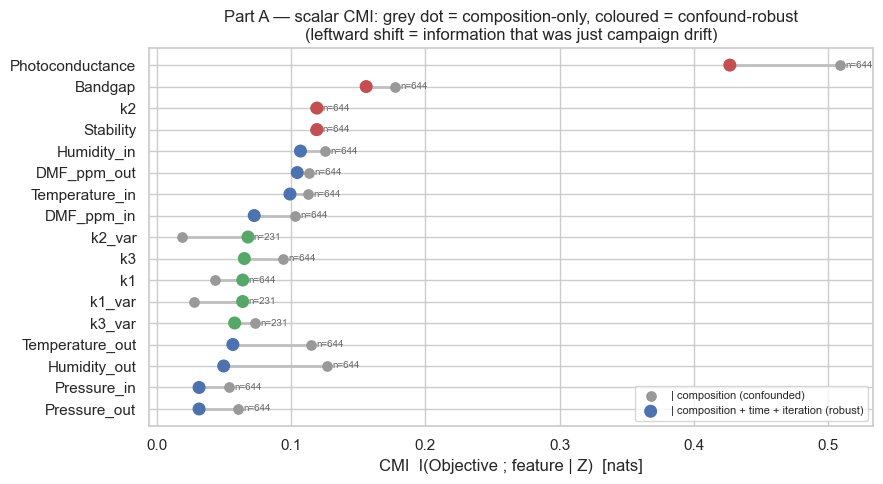

In [45]:
# Confound view: composition-only vs composition+time+iteration, sorted by the robust value
palette = {"sub-target (definitional)": "#c44e52", "environment": "#4c72b0", "kinetics": "#55a868"}
m = cmi_scalar.sort_values("cmi_full")
fig, ax = plt.subplots(figsize=(9, 5))
ypos = np.arange(len(m))
ax.hlines(ypos, m["cmi_full"], m["cmi_comp"], color="0.75", lw=2, zorder=1)
ax.scatter(m["cmi_comp"], ypos, color="0.6", s=45, label="| composition (confounded)", zorder=2)
ax.scatter(m["cmi_full"], ypos, color=[palette[k] for k in m["kind"]], s=70,
           label="| composition + time + iteration (robust)", zorder=3)
ax.set_yticks(ypos); ax.set_yticklabels(m["feature"])
for i, (_, r) in enumerate(m.iterrows()):
    ax.text(max(r["cmi_comp"], r["cmi_full"]) + 0.004, i, f"n={r['n']}", va="center",
            fontsize=7, color="0.4")
ax.set_xlabel("CMI  I(Objective ; feature | Z)  [nats]")
ax.set_title("Part A — scalar CMI: grey dot = composition-only, coloured = confound-robust\n"
             "(leftward shift = information that was just campaign drift)")
ax.legend(fontsize=8, loc="lower right"); plt.tight_layout(); plt.show()

In [46]:
# Significance of the top genuinely-discovered scalars under the FULL conditioning
discovered = cmi_scalar[~cmi_scalar.feature.isin(sub_targets)].head(4)
print("Permutation test (100 perms) under Z = composition + time + iteration:\n")
for _, r in discovered.iterrows():
    x = df[r.feature].values
    mask = np.isfinite(x) & np.isfinite(OBJ) & np.isfinite(COND_FULL).all(1)
    obs, p = cmi_pvalue(x[mask], OBJ[mask], COND_FULL[mask], k=5, n_perm=100, seed=1)
    print(f"  {r.feature:16} CMI_full={obs:.3f}  p={p:.3f}  {'*' if p < 0.05 else ''}")

Permutation test (100 perms) under Z = composition + time + iteration:

  Humidity_in      CMI_full=0.107  p=0.010  *
  DMF_ppm_out      CMI_full=0.105  p=0.010  *
  Temperature_in   CMI_full=0.099  p=0.020  *
  DMF_ppm_in       CMI_full=0.073  p=0.149  


## Part B&nbsp;&middot;&nbsp;Functional-PCA of the large feature groups

Three groups are really *curves*, not independent scalars, so their columns are highly
correlated and estimating CMI on each raw column is both wasteful and noisy. We compress
each with **functional PCA**: smooth every sample's curve onto a B-spline basis, then take
the leading eigen-functions. A few scores capture almost all of the variation.

| group | functional index | raw dims | how we treat it |
|---|---|---|---|
| absorption | wavelength 387–1003 nm | 462 | curve over λ |
| stability sweep | voltage −40…+40 | 120 | avg 3 reps → **dark(V)** & **light(V)** curves |
| PL initial / final | wavelength 450–1042 nm | 30 each | curve over λ |

In [47]:
def fpca_scores(values, grid, n_basis=15, n_comp=4, name=""):
    """Smooth curves onto a B-spline basis, then FPCA. Returns (scores[n,n_comp], fpca, valid_mask)."""
    V = np.asarray(values, float)
    valid = np.isfinite(V).mean(1) > 0.5           # keep rows that are mostly present
    Vv = V[valid]
    col_mean = np.nanmean(Vv, 0)
    Vv = np.where(np.isfinite(Vv), Vv, col_mean)   # impute stray NaNs with column mean
    fd = FDataGrid(Vv, grid_points=grid)
    basis = BSplineBasis(n_basis=n_basis, domain_range=(float(grid.min()), float(grid.max())))
    fp = FPCA(n_components=n_comp)
    scores = fp.fit_transform(fd.to_basis(basis))
    print(f"{name:14} n={valid.sum():4d}  EVR={np.round(fp.explained_variance_ratio_,3)}"
          f"  cum={fp.explained_variance_ratio_[:n_comp].sum():.3f}")
    full = np.full((len(V), n_comp), np.nan)
    full[valid] = scores
    return full, fp, fd, basis

# ---- absorption: curve over wavelength ----
wl_abs = np.array([float(c) for c in ABSORP])
abs_scores, abs_fp, abs_fd, abs_basis = fpca_scores(df[ABSORP].values, wl_abs,
                                                    n_basis=20, n_comp=4, name="absorption")

# ---- stability sweep: average the 3 repeats -> dark(V) and light(V) ----
volts = sorted({int(c.split("_")[0]) for c in STAB})
def sweep_curve(cond):
    cols_by_v = [[f"{v}_{cond}_{r}" for r in (1, 2, 3)] for v in volts]
    return np.stack([df[cs].mean(axis=1).values for cs in cols_by_v], axis=1)  # [n, nV]
dark = sweep_curve("dark"); light = sweep_curve("light")
vgrid = np.array(volts, float)
dark_scores,  dark_fp,  dark_fd,  dark_basis  = fpca_scores(dark,  vgrid, n_basis=8, n_comp=3, name="stability_dark")
light_scores, light_fp, light_fd, light_basis = fpca_scores(light, vgrid, n_basis=8, n_comp=3, name="stability_light")

# ---- PL spectra: curve over wavelength ----
wl_pl = np.array([int(c.split("_")[0]) for c in IPL], float)
ipl_scores, ipl_fp, ipl_fd, ipl_basis = fpca_scores(df[IPL].values, wl_pl, n_basis=10, n_comp=3, name="PL_initial")
fpl_scores, fpl_fp, fpl_fd, fpl_basis = fpca_scores(df[FPL].values, wl_pl, n_basis=10, n_comp=3, name="PL_final")

absorption     n= 953  EVR=[0.815 0.127 0.023 0.016]  cum=0.981
stability_dark n= 870  EVR=[0.99  0.008 0.002]  cum=1.000
stability_light n= 870  EVR=[0.99  0.01  0.001]  cum=1.000
PL_initial     n= 247  EVR=[0.807 0.129 0.036]  cum=0.971
PL_final       n= 247  EVR=[0.911 0.08  0.008]  cum=0.999


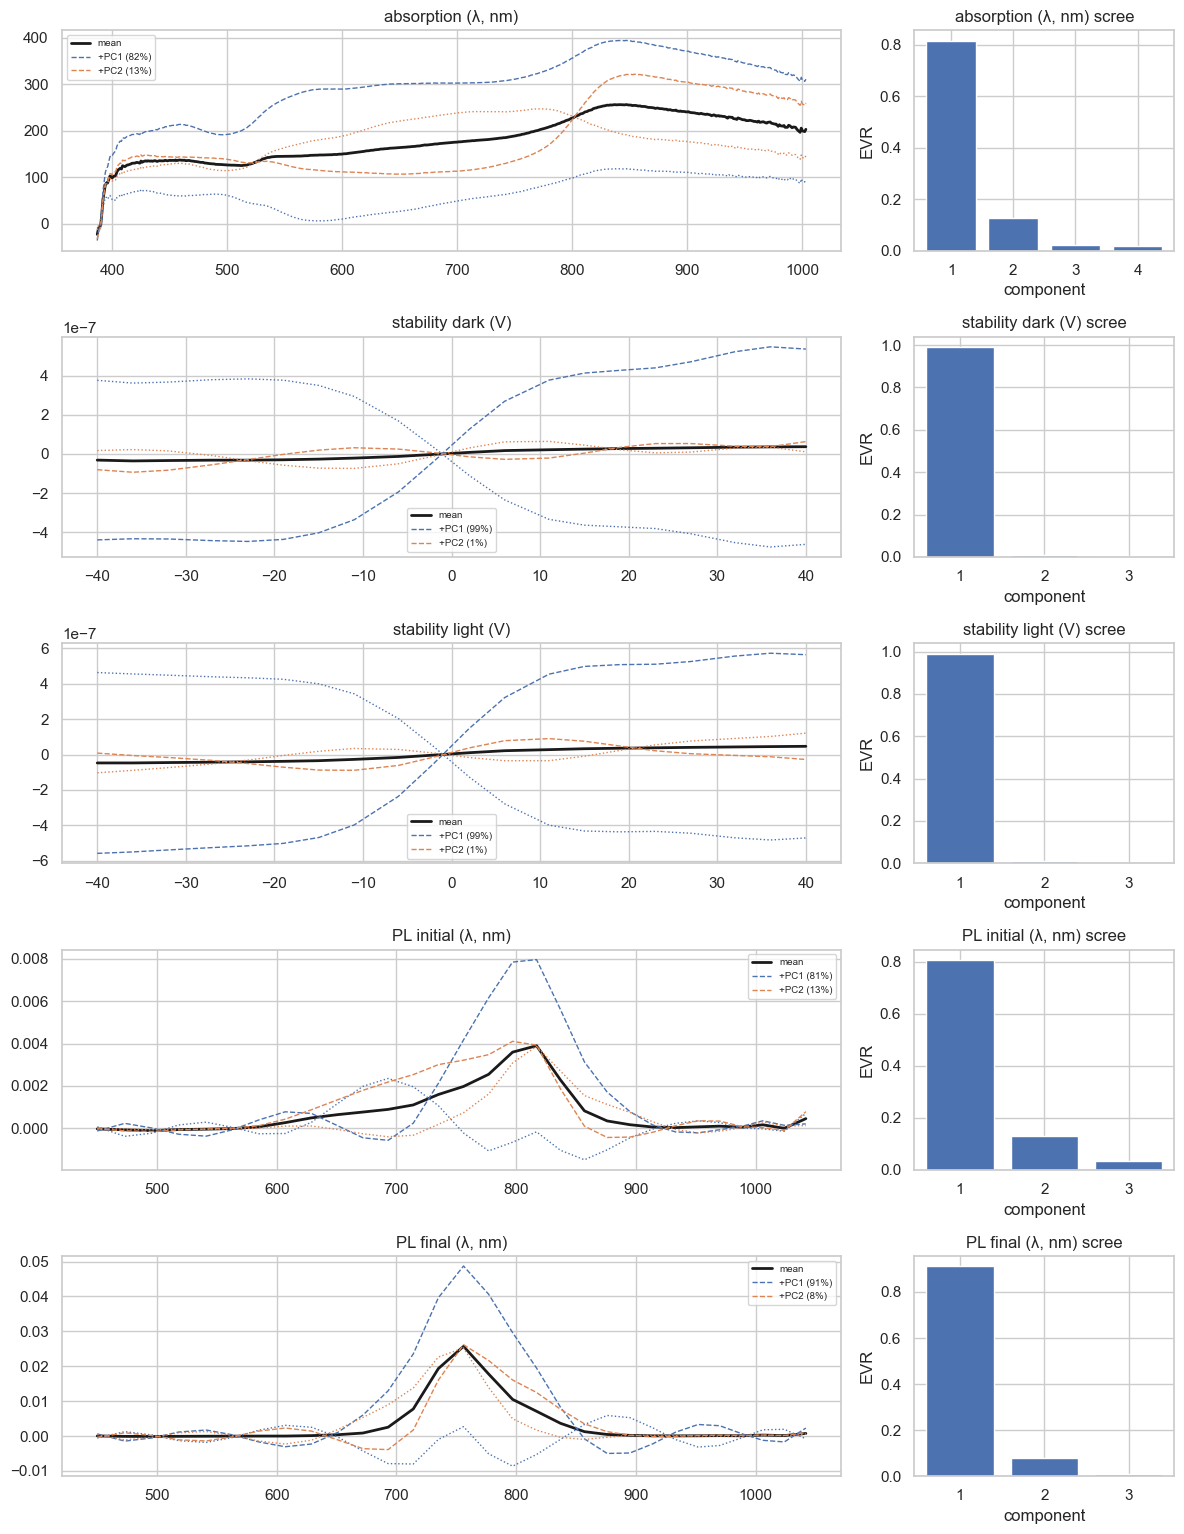

In [48]:
# Visualise: mean curve +/- leading eigen-functions, and scree, for each group
def plot_fpca(fp, fd, basis, grid, title, ax_curve, ax_scree):
    mean = fd.mean().to_grid(grid).data_matrix.ravel()
    comps = fp.components_.to_grid(grid).data_matrix.reshape(fp.n_components, -1)
    sd = np.sqrt(fp.explained_variance_)
    ax_curve.plot(grid, mean, "k", lw=2, label="mean")
    for i in range(min(2, fp.n_components)):
        ax_curve.plot(grid, mean + sd[i]*comps[i], "--", lw=1,
                      label=f"+PC{i+1} ({fp.explained_variance_ratio_[i]*100:.0f}%)")
        ax_curve.plot(grid, mean - sd[i]*comps[i], ":", lw=1, color=ax_curve.lines[-1].get_color())
    ax_curve.set_title(title); ax_curve.legend(fontsize=7)
    ax_scree.bar(range(1, fp.n_components+1), fp.explained_variance_ratio_, color="#4c72b0")
    ax_scree.set_xlabel("component"); ax_scree.set_ylabel("EVR"); ax_scree.set_title(f"{title} scree")

specs = [(abs_fp, abs_fd, abs_basis, wl_abs, "absorption (λ, nm)"),
         (dark_fp, dark_fd, dark_basis, vgrid, "stability dark (V)"),
         (light_fp, light_fd, light_basis, vgrid, "stability light (V)"),
         (ipl_fp, ipl_fd, ipl_basis, wl_pl, "PL initial (λ, nm)"),
         (fpl_fp, fpl_fd, fpl_basis, wl_pl, "PL final (λ, nm)")]
fig, axes = plt.subplots(len(specs), 2, figsize=(12, 3.1*len(specs)),
                         gridspec_kw={"width_ratios": [3, 1]})
for (fp, fd, basis, grid, title), (axc, axs) in zip(specs, axes):
    plot_fpca(fp, fd, basis, grid, title, axc, axs)
plt.tight_layout(); plt.show()

## Part C&nbsp;&middot;&nbsp;CMI of the objective vs the fPCA scores | composition

Now the same conditional-MI question, but on the compressed functional features. Each bar is
one eigen-function score of one group; height = information about `Objective` beyond composition.

In [49]:
score_sets = {
    "absorption":     (abs_scores,   "absorp"),
    "stability_dark": (dark_scores,  "stab_dark"),
    "stability_light":(light_scores, "stab_light"),
    "PL_initial":     (ipl_scores,   "PLi"),
    "PL_final":       (fpl_scores,   "PLf"),
}
rows = []
for group, (scores, short) in score_sets.items():
    for j in range(scores.shape[1]):
        c_comp, c_full, n = cmi_both(scores[:, j], k=5)
        if n < 50:
            continue
        rows.append({"feature": f"{short}_fPC{j+1}", "group": group,
                     "cmi_comp": c_comp, "cmi_full": c_full,
                     "confound": c_comp - c_full, "n": n})
cmi_func = pd.DataFrame(rows).sort_values("cmi_full", ascending=False).reset_index(drop=True)
cmi_func.round(3)

,feature,group,cmi_comp,cmi_full,confound,n
0,absorp_fPC1,absorption,0.076,0.102,-0.025,644
1,absorp_fPC3,absorption,0.090,0.099,-0.009,644
2,absorp_fPC2,absorption,0.121,0.096,0.025,644
3,absorp_fPC4,absorption,0.069,0.068,0.002,644
4,PLf_fPC2,PL_final,0.017,0.040,-0.022,231
5,PLi_fPC2,PL_initial,0.035,0.038,-0.003,231
6,stab_dark_fPC1,stability_dark,0.004,0.035,-0.031,644
7,stab_light_fPC3,stability_light,0.013,0.033,-0.021,644
8,stab_dark_fPC2,stability_dark,0.004,0.033,-0.029,644
9,stab_light_fPC1,stability_light,0.004,0.033,-0.029,644


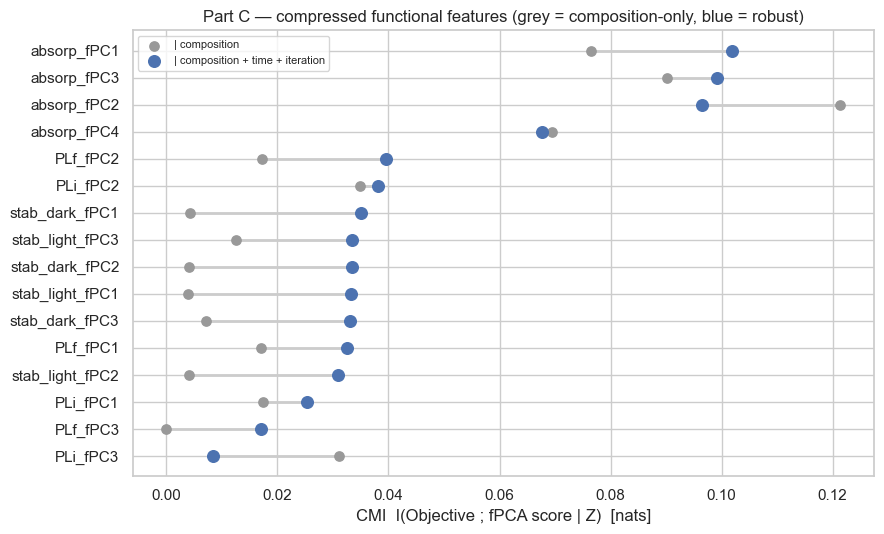

In [50]:
m = cmi_func.sort_values("cmi_full")
fig, ax = plt.subplots(figsize=(9, 5.5))
ypos = np.arange(len(m))
ax.hlines(ypos, m["cmi_full"], m["cmi_comp"], color="0.8", lw=2, zorder=1)
ax.scatter(m["cmi_comp"], ypos, color="0.6", s=45, label="| composition", zorder=2)
ax.scatter(m["cmi_full"], ypos, color="#4c72b0", s=70, label="| composition + time + iteration", zorder=3)
ax.set_yticks(ypos); ax.set_yticklabels(m["feature"])
ax.set_xlabel("CMI  I(Objective ; fPCA score | Z)  [nats]")
ax.set_title("Part C — compressed functional features (grey = composition-only, blue = robust)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

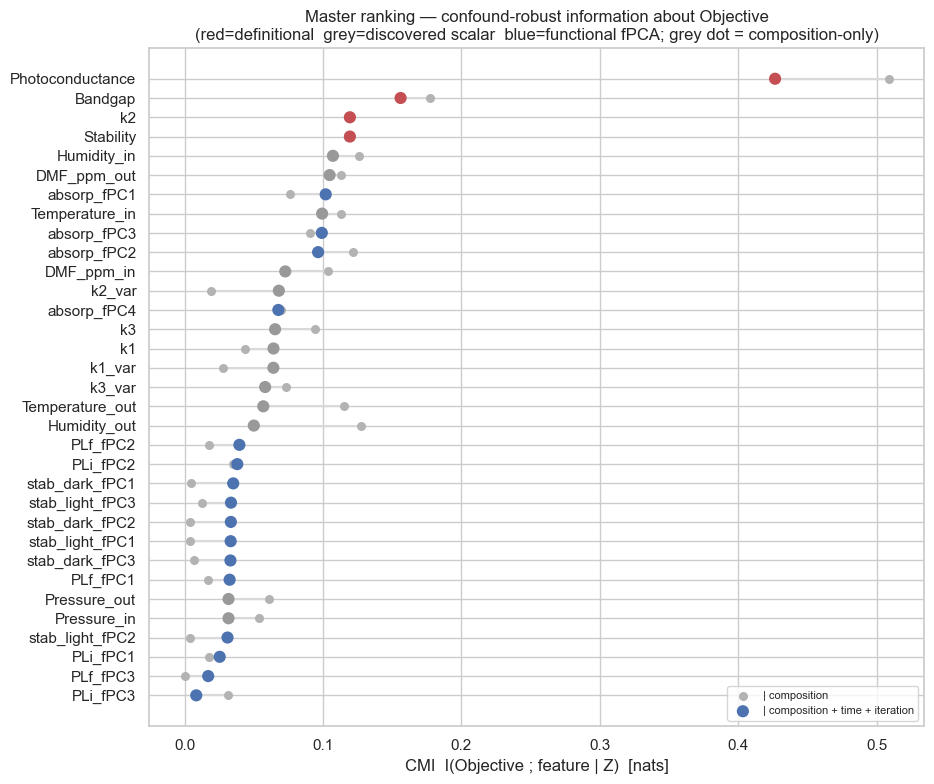

,feature,cmi_comp,cmi_full,n,group
0,Photoconductance,0.509,0.427,644,sub-target (definitional)
1,Bandgap,0.178,0.156,644,sub-target (definitional)
2,k2,0.118,0.119,644,sub-target (definitional)
3,Stability,0.118,0.119,644,sub-target (definitional)
4,Humidity_in,0.126,0.107,644,environment
5,DMF_ppm_out,0.113,0.105,644,environment
6,absorp_fPC1,0.076,0.102,644,absorption
7,Temperature_in,0.113,0.099,644,environment
8,absorp_fPC3,0.090,0.099,644,absorption
9,absorp_fPC2,0.121,0.096,644,absorption


In [51]:
# ---- Master ranking on the confound-robust CMI (everything on one axis) ----
master = pd.concat([
    cmi_scalar.rename(columns={"kind": "group"})[["feature", "cmi_comp", "cmi_full", "n", "group"]],
    cmi_func[["feature", "cmi_comp", "cmi_full", "n", "group"]],
], ignore_index=True).sort_values("cmi_full", ascending=False).reset_index(drop=True)

def _c(g):
    if "sub-target" in g:                    return "#c44e52"   # definitional
    if g in ("environment", "kinetics"):     return "#999999"   # discovered scalar
    return "#4c72b0"                                            # functional fPCA
m = master.sort_values("cmi_full")
plt.figure(figsize=(9.5, 8))
ax = plt.gca(); ypos = np.arange(len(m))
ax.hlines(ypos, m["cmi_full"], m["cmi_comp"], color="0.85", lw=1.5, zorder=1)
ax.scatter(m["cmi_comp"], ypos, color="0.7", s=30, zorder=2, label="| composition")
ax.scatter(m["cmi_full"], ypos, color=[_c(g) for g in m["group"]], s=60, zorder=3,
           label="| composition + time + iteration")
ax.set_yticks(ypos); ax.set_yticklabels(m["feature"])
ax.set_xlabel("CMI  I(Objective ; feature | Z)  [nats]")
ax.set_title("Master ranking — confound-robust information about Objective\n"
             "(red=definitional  grey=discovered scalar  blue=functional fPCA; "
             "grey dot = composition-only)")
ax.legend(fontsize=8, loc="lower right"); plt.tight_layout(); plt.show()
master.round(3).head(20)

## Part D&nbsp;&middot;&nbsp;What still varies with time *after* we control for composition?

Parts A–C measured information about the **objective**. This part asks a different, upstream
question about **each feature itself**: is its variation driven by *where we are in the
simplex* (composition), by *when in the campaign it was measured* (time / iteration), or
both? This is what decides, for the generative surrogate, which variables each feature's
conditional mean should be regressed on.

> **Read the cadence cell below first.** `_time_sec` is **not continuous** — it takes only
> **41 distinct values, one per BO iteration** (each a batch of ~24 spots), clustered into
> **3 measurement sessions** with long overnight gaps. So "time" here behaves as a 41-level
> **batch label**, and everything about "time dependence" below is really about
> **batch-to-batch offsets**, not a smooth wall-clock drift.

Every quantity below is an **out-of-bag (OOB) $R^2$** of a random forest: each tree is scored
only on the rows it did **not** train on, so these are honest held-out numbers, never
in-sample (an RF fits its own training rows almost perfectly, which would make in-sample
$R^2$ meaningless here). OOB $R^2$ can be **negative** — that just means the forest predicts
worse than a constant, i.e. *no learnable signal* from those inputs.

Let $\text{comp} = (\text{FAPbI3},\text{MAPbI3},\text{MAPbBr3})$ and $t = $ `_time_sec`
(`Iteration` is the same axis, $\rho = 1.00$).

| symbol | precise definition | reads as |
|---|---|---|
| **`R2_comp`** | OOB $R^2$ of $\text{RF}(\text{comp}) \to \text{feature}$ | fraction of the feature's variance recoverable from composition alone |
| **`R2_time`** | OOB $R^2$ of $\text{RF}(t) \to \text{feature}$ | …recoverable from the time/iteration label alone |
| **`R2_both`** | OOB $R^2$ of $\text{RF}(\text{comp}, t) \to \text{feature}$ | …recoverable from both together |
| **`d_time`** | `R2_both − R2_comp` | **extra** variance time explains *on top of* composition |
| **`d_comp`** | `R2_both − R2_time` | **extra** variance composition explains *on top of* time |
| **`rT`** | Spearman $\rho\big(\text{feature} - \widehat{E}[\text{feature}\mid\text{comp}],\; t\big)$ | **monotonic** drift left in the composition-only **residual** (signed) |
| **`R2_rT`** | OOB $R^2$ of $\text{RF}(t) \to (\text{feature} - \widehat{E}[\text{feature}\mid\text{comp}])$ | **any** leftover time signal — because $t$ is a 41-level label, this mostly captures **between-batch** offset variance |

**`R2_rT` vs `rT` — read them together.** If a feature's time-dependence were merely a
composition$\leftrightarrow$time artifact (the BO path samples different compositions in
different iterations), then once composition is regressed out its residual would be
batch-flat and `R2_rT ≈ 0`. A **positive** `R2_rT` means the feature genuinely varies with
the iteration/batch label *beyond* anything composition encodes. But **`R2_rT` alone does not
imply a smooth trend**: because $t$ is effectively categorical, a large `R2_rT` with a
**small `|rT|`** means the residual jumps up and down **between batches** (a batch/session
effect), not a monotonic drift over the 54 h. (E.g. `absorp_fPC1`: `R2_rT≈0.56` but
`rT≈−0.22` — big batch offsets, little monotonic trend.)

**How to read the verdict:**
- `d_comp ≈ 0` and `R2_time` high &rarr; **time/batch-only** (composition irrelevant): the environment.
- `d_time > 0` **and** `R2_rT > 0` &rarr; composition **plus** a real batch effect (large `|rT|` ⇒ also a monotonic trend; small `|rT|` ⇒ non-monotonic batch offsets).
- `d_time ≈ 0` and `R2_rT ≈ 0` &rarr; **composition-only** (time was just the BO path).

953 spots  |  41 unique iterations == 41 unique timestamps  |  span 54.3 h
Time is therefore effectively a 41-level BATCH label (one timestamp per BO iteration),
clustered into 3 sessions with long overnight gaps -- NOT a continuous axis.


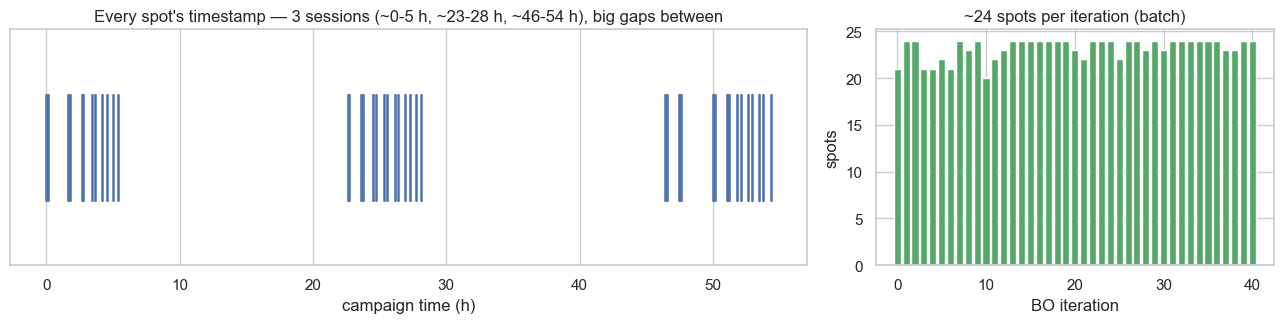

In [52]:
# Measurement cadence: WHEN were spots actually collected? (this shapes everything below)
th = df["_time_sec"].values / 3600.0
print(f"{len(df)} spots  |  {df['Iteration'].nunique()} unique iterations "
      f"== {len(np.unique(df['_time_sec']))} unique timestamps  |  span {th.max():.1f} h")
print("Time is therefore effectively a 41-level BATCH label (one timestamp per BO iteration),\n"
      "clustered into 3 sessions with long overnight gaps -- NOT a continuous axis.")

fig, (a0, a1) = plt.subplots(1, 2, figsize=(13, 3.4), gridspec_kw={"width_ratios": [2, 1]})
a0.eventplot([th], colors="#4c72b0", lineoffsets=0, linelengths=0.8, linewidths=0.8)
a0.set_yticks([]); a0.set_xlabel("campaign time (h)")
a0.set_title("Every spot's timestamp — 3 sessions (~0-5 h, ~23-28 h, ~46-54 h), big gaps between")
cnt = df.groupby("Iteration").size()
a1.bar(cnt.index, cnt.values, color="#55a868")
a1.set_xlabel("BO iteration"); a1.set_ylabel("spots"); a1.set_title("~24 spots per iteration (batch)")
plt.tight_layout(); plt.show()


In [53]:
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import spearmanr

RF_KW = dict(n_estimators=300, oob_score=True, n_jobs=-1, random_state=0)

def _oob(Xin, y):
    """Out-of-bag R^2 and OOB predictions of an RF mapping Xin -> y."""
    rf = RandomForestRegressor(**RF_KW).fit(Xin, y)
    return rf.oob_score_, rf.oob_prediction_

comp_mat = df[COMP].values                        # (n,3) composition (FAPbI3, MAPbI3, MAPbBr3)
time_vec = df["_time_sec"].values.reshape(-1, 1)  # (n,1) wall-clock time (Iteration == time)

# Every feature in the joint model: scalar sub-targets + kinetics + environment,
# plus the fPCA scores of the curve groups (reusing score_sets from Part C).
feat_items = []   # (name, values, group)
for c in ["Bandgap", "Photoconductance", "Stability"]:
    feat_items.append((c, df[c].values, "sub-target"))
for c in KIN:
    feat_items.append((c, df[c].values, "kinetics"))
for c in ENV:
    feat_items.append((c, df[c].values, "environment"))
for group, (scores, short) in score_sets.items():
    for j in range(scores.shape[1]):
        feat_items.append((f"{short}_fPC{j+1}", scores[:, j], group))

rows = []
for name, vals, group in feat_items:
    vals = np.asarray(vals, float)
    m = np.isfinite(vals) & np.isfinite(comp_mat).all(1) & np.isfinite(time_vec).all(1)
    if m.sum() < 50:
        continue
    y = vals[m]
    r2_comp, oob_comp = _oob(comp_mat[m], y)                       # feature | composition
    r2_time, _        = _oob(time_vec[m], y)                       # feature | time
    r2_both, _        = _oob(np.column_stack([comp_mat[m], time_vec[m]]), y)  # feature | comp + time
    resid = y - oob_comp                                           # what composition can't explain
    rT = spearmanr(resid, time_vec[m, 0]).correlation             # monotonic leftover drift
    r2_rT, _ = _oob(time_vec[m], resid)                            # de-confounded leftover-time R^2
    rows.append({"feature": name, "group": group, "n": int(m.sum()),
                 "R2_comp": r2_comp, "R2_time": r2_time, "R2_both": r2_both,
                 "d_time": r2_both - r2_comp, "d_comp": r2_both - r2_time,
                 "rT": rT, "R2_rT": r2_rT})

# Sort by R2_rT: the features whose composition-only residual is MOST explained by time.
parent_diag = pd.DataFrame(rows).sort_values("R2_rT", ascending=False).reset_index(drop=True)
parent_diag.round(3)


,feature,group,n,R2_comp,R2_time,R2_both,d_time,d_comp,rT,R2_rT
0,DMF_ppm_out,environment,953,0.123,1.000,0.990,0.866,-0.010,0.284,0.698
1,DMF_ppm_in,environment,953,0.175,1.000,0.994,0.819,-0.006,0.442,0.661
2,Temperature_out,environment,953,0.185,1.000,1.000,0.814,-0.000,0.124,0.638
3,Temperature_in,environment,953,0.229,1.000,0.986,0.757,-0.014,0.085,0.602
4,Pressure_in,environment,953,0.251,1.000,1.000,0.749,-0.000,0.623,0.585
5,Pressure_out,environment,953,0.253,1.000,1.000,0.747,-0.000,0.639,0.585
6,Humidity_out,environment,953,0.303,1.000,1.000,0.697,-0.000,-0.529,0.564
7,absorp_fPC1,absorption,953,0.267,0.919,0.961,0.693,0.042,-0.215,0.559
8,Humidity_in,environment,953,0.323,1.000,0.986,0.663,-0.014,-0.377,0.553
9,Stability,sub-target,684,0.063,0.333,0.648,0.585,0.315,-0.088,0.232


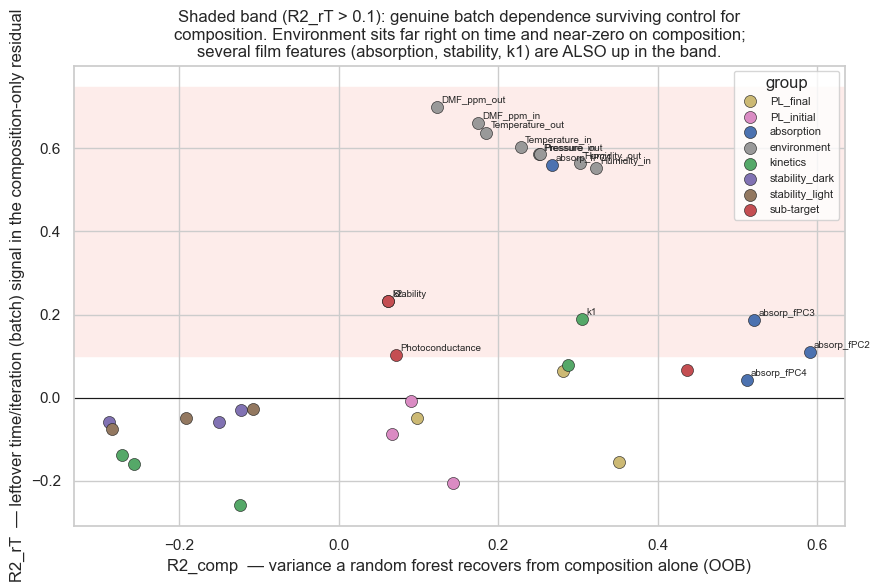

In [54]:
# Map: how much composition explains (x) vs how much time/iteration is STILL left after
# removing composition (y). Points in the shaded band carry genuine batch dependence that is
# NOT a composition<->iteration (BO-path) artifact. (High y with small |rT| => batch offsets,
# not a smooth drift -- see the per-iteration panels below.)
pal = {"sub-target": "#c44e52", "kinetics": "#55a868", "absorption": "#4c72b0",
       "stability_dark": "#8172b3", "stability_light": "#937860",
       "PL_initial": "#da8bc3", "PL_final": "#ccb974", "environment": "#999999"}

fig, ax = plt.subplots(figsize=(9, 6))
ax.axhspan(0.1, max(0.7, parent_diag["R2_rT"].max() + 0.05), color="#fdecea", zorder=0)
for g, sub in parent_diag.groupby("group"):
    ax.scatter(sub["R2_comp"], sub["R2_rT"], s=75, color=pal.get(g, "0.5"),
               label=g, edgecolor="k", linewidth=0.4, zorder=3)
ax.axhline(0, color="k", lw=0.8)
for _, r in parent_diag.iterrows():
    if r["R2_rT"] > 0.1 or r["R2_comp"] > 0.5:
        ax.annotate(r["feature"], (r["R2_comp"], r["R2_rT"]), fontsize=7,
                    xytext=(3, 3), textcoords="offset points")
ax.set_xlabel("R2_comp  — variance a random forest recovers from composition alone (OOB)")
ax.set_ylabel("R2_rT  — leftover time/iteration (batch) signal in the composition-only residual")
ax.set_title("Shaded band (R2_rT > 0.1): genuine batch dependence surviving control for\n"
             "composition. Environment sits far right on time and near-zero on composition;\n"
             "several film features (absorption, stability, k1) are ALSO up in the band.")
ax.legend(fontsize=8, title="group", loc="upper right")
plt.tight_layout(); plt.show()


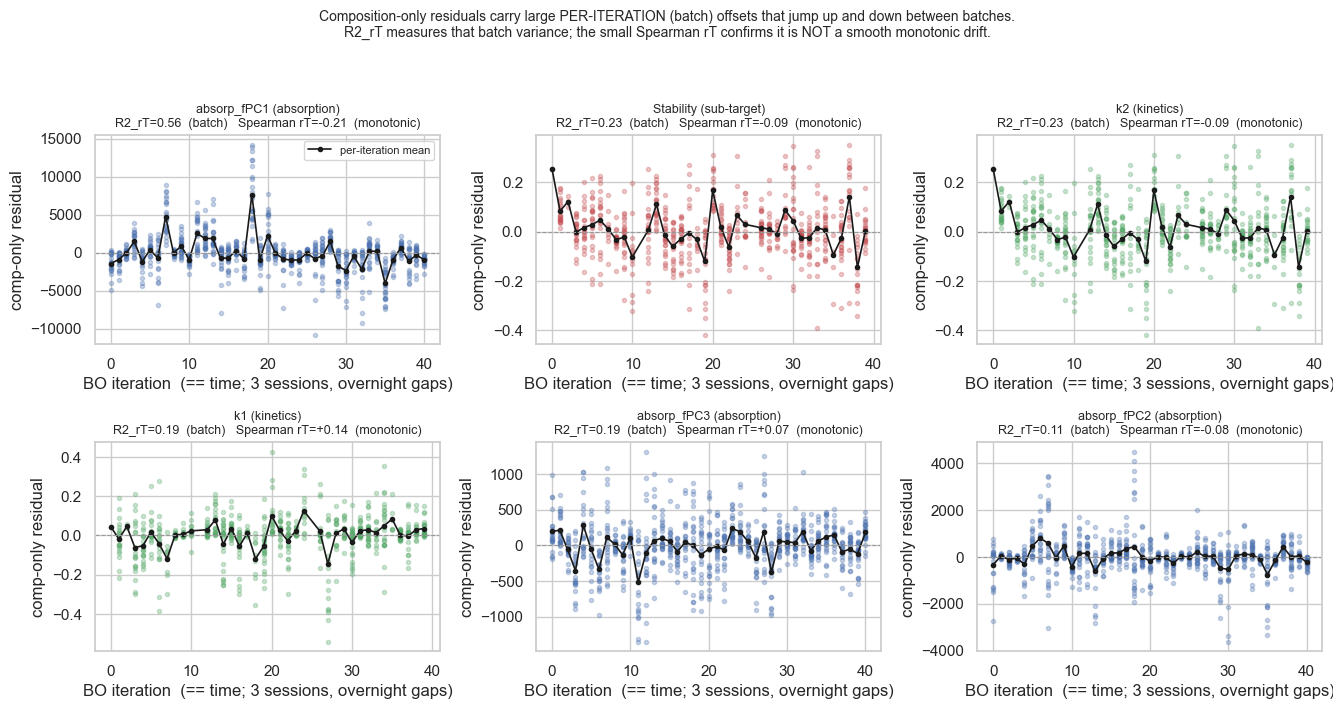

In [55]:
# What the leftover-time signal REALLY is: time is not continuous -- it is 41 BO iterations
# (batches of ~24 spots) clustered into 3 sessions. So `R2_rT` captures a per-iteration
# BATCH offset, not a smooth drift. Plot the composition-only residual against iteration with
# the per-iteration mean overlaid: if a feature were truly composition-only these batch means
# would scatter around 0 within noise; instead many batches sit systematically off-zero, and
# they jump up/down between batches (non-monotonic -> that is why Spearman rT is small even
# though R2_rT is large).
pal = {"sub-target": "#c44e52", "kinetics": "#55a868", "absorption": "#4c72b0",
       "stability_dark": "#8172b3", "stability_light": "#937860",
       "PL_initial": "#da8bc3", "PL_final": "#ccb974", "environment": "#999999"}

film = parent_diag[parent_diag.group != "environment"].nlargest(6, "R2_rT")
iters = df["Iteration"].values
feat_lookup = {name: (np.asarray(vals, float), group) for name, vals, group in feat_items}

fig, axes = plt.subplots(2, 3, figsize=(13.5, 6.8))
for ax, (_, r) in zip(axes.ravel(), film.iterrows()):
    vals, group = feat_lookup[r["feature"]]
    m = np.isfinite(vals) & np.isfinite(comp_mat).all(1)
    _, oob_comp = _oob(comp_mat[m], vals[m])
    resid = vals[m] - oob_comp
    it = iters[m]
    ax.scatter(it, resid, s=9, alpha=0.3, color=pal.get(group, "0.5"))
    uni = np.unique(it)
    mu = np.array([resid[it == u].mean() for u in uni])
    ax.plot(uni, mu, "k-o", ms=3, lw=1.2, label="per-iteration mean")
    ax.axhline(0, color="0.6", lw=0.8, ls="--")
    ax.set_title(f"{r['feature']} ({group})\n"
                 f"R2_rT={r['R2_rT']:.2f}  (batch)   Spearman rT={r['rT']:+.2f}  (monotonic)",
                 fontsize=9)
    ax.set_xlabel("BO iteration  (== time; 3 sessions, overnight gaps)")
    ax.set_ylabel("comp-only residual")
axes.ravel()[0].legend(fontsize=8)
fig.suptitle("Composition-only residuals carry large PER-ITERATION (batch) offsets that jump "
             "up and down between batches.\nR2_rT measures that batch variance; the small "
             "Spearman rT confirms it is NOT a smooth monotonic drift.", y=1.04, fontsize=10)
plt.tight_layout(); plt.show()


### Environment: a per-iteration logged condition, not a material property

The environment channels are a different animal from the film measurements. Two facts
(confirmed below):

* **Exactly constant within each iteration** (within-iteration std / total std = **0**): there
  is one ambient reading per batch of ~24 spots.
* **No composition signal** (`d_comp ≈ 0` in the table above): composition only *appears* to
  predict them, through its confound with the iteration axis.

So each channel is effectively a **deterministic per-iteration value**. Across the 41
iterations some drift fairly smoothly (`Pressure`, `Humidity_out`) while others are jumpy with
no clear trend (`Temperature`, `DMF_ppm_out`) — but every one is *fully determined by the
iteration label*, which is why `R2_time = 1.00` (predictability, not smoothness — same lesson
as `R2_rT` vs `rT`). Because the optimizer also improves the objective over the same
iterations, this shared axis is what makes the environment look spuriously informative about
the objective (the confound quantified in Part A). In the surrogate this is why the
environment is conditioned on the **iteration/time label, not composition**.

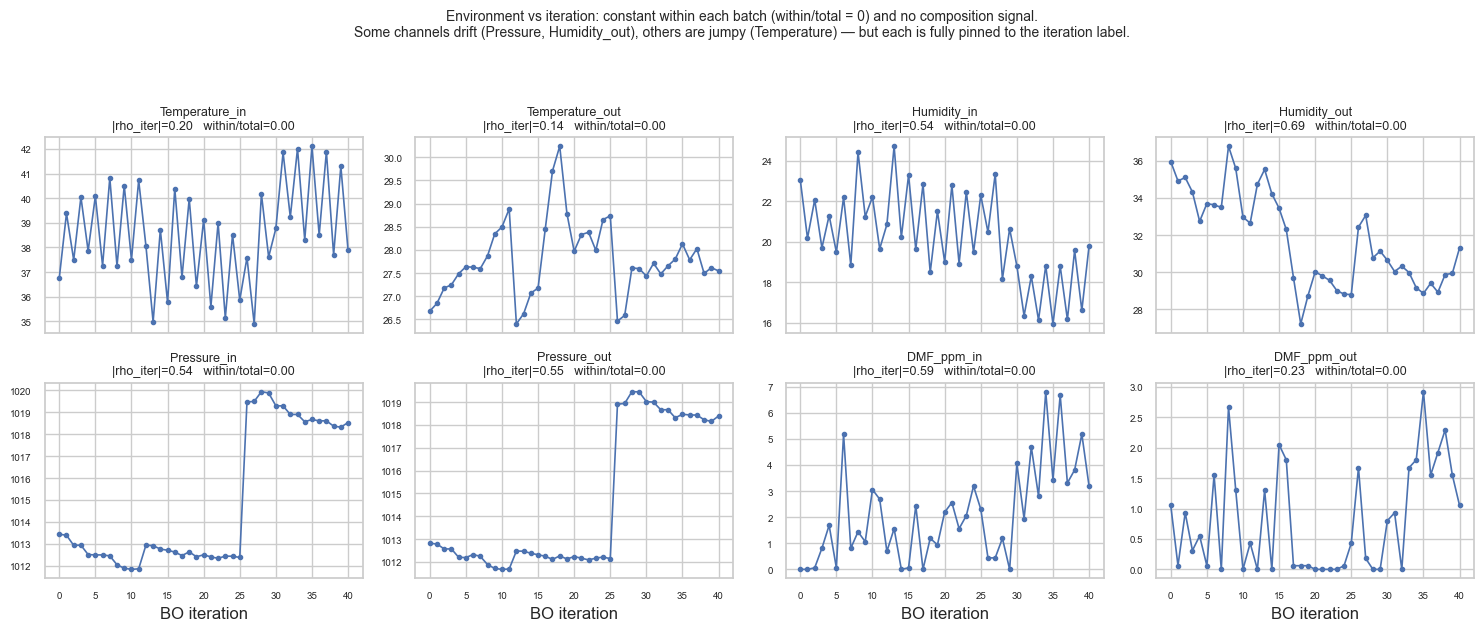

,spearman_vs_iteration,abs_rho
Humidity_out,-0.679,0.679
DMF_ppm_in,0.603,0.603
Pressure_out,0.553,0.553
Pressure_in,0.546,0.546
Humidity_in,-0.543,0.543
DMF_ppm_out,0.236,0.236
Temperature_in,0.199,0.199
Temperature_out,0.132,0.132


In [56]:
# Environment vs ITERATION (consistent with the per-iteration panels above). Each channel is
# constant within an iteration, so we plot its single per-iteration value. Titles show the
# monotonic trend strength (|rho| with iteration) and the within/total ratio (= 0 -> constant
# within batch).
its = np.sort(df["Iteration"].unique())
fig, axes = plt.subplots(2, 4, figsize=(15, 6), sharex=True)
for ax, c in zip(axes.ravel(), ENV):
    per_it = df.groupby("Iteration")[c].mean().reindex(its)
    win = df.groupby("Iteration")[c].std().mean() / df[c].std()      # within-iter / total
    rho = spearmanr(per_it.index.values, per_it.values).correlation
    ax.plot(per_it.index, per_it.values, "-o", ms=3, lw=1.2, color="#4c72b0")
    ax.set_title(f"{c}\n|rho_iter|={abs(rho):.2f}   within/total={win:.2f}", fontsize=9)
    ax.tick_params(labelsize=7)
for ax in axes[-1]:
    ax.set_xlabel("BO iteration")
fig.suptitle("Environment vs iteration: constant within each batch (within/total = 0) and no "
             "composition signal.\nSome channels drift (Pressure, Humidity_out), others are "
             "jumpy (Temperature) — but each is fully pinned to the iteration label.",
             y=1.05, fontsize=10)
plt.tight_layout(); plt.show()

# Rank channels by monotonic trend with the iteration axis.
env_drift = (pd.DataFrame({c: [spearmanr(df["Iteration"].values, df[c].values).correlation]
                           for c in ENV}, index=["spearman_vs_iteration"]).T
             .assign(abs_rho=lambda d: d["spearman_vs_iteration"].abs())
             .sort_values("abs_rho", ascending=False))
env_drift.round(3)


## Summary

- **Composition is a ternary simplex** (`FAPbI3+MAPbI3+MAPbBr3 ≡ 1`, ~all-unique rows); the
  `Module1–7` columns are identically zero and were dropped.
- **CMI was estimated with the KSG / Frenzel–Pompe kNN estimator** (nats, ≥0), under two
  conditioning sets: composition only vs **composition + wall-clock time + iteration**. The gap
  between them is the size of the campaign's temporal confound.
- **The temporal confound is large for the environment channels.** The glovebox drifts over the
  2.3-day run while the optimizer improves the objective, so environment looks informative for
  spurious reasons. Adding time + iteration collapses e.g. `Humidity_out` by ~60%, while the true
  sub-targets are unaffected. Read the **`cmi_full`** column / coloured dots, not `cmi_comp`.
- **`k2` was moved to the definitional group** — it equals `Stability` ($\rho=1.00$); the
  stability score is derived from it. Only `k1`, `k3` are genuine kinetics.
- **Part A (scalars):** after de-confounding, the definitional sub-targets
  (`Photoconductance` ≫ `Bandgap` ≈ `Stability`/`k2`) dominate as they must. `DMF_ppm` is the one
  environmental channel whose signal survives time+iteration conditioning (a plausible real
  effect on film quality); most other environment CMI was drift.
- **Part B (fPCA):** each functional group compresses to a few eigen-functions capturing the
  large majority of variance (absorption ≈4 comps, sweeps ≈3, PL ≈3), turning ~640 raw
  spectral/sweep columns into ~17 interpretable scores.
- **Part C + master ranking:** puts the compressed spectral/sweep/PL features on the same
  confound-robust axis as the scalars; the absorption eigen-functions are the most informative
  of the measured *curves* once composition, time and iteration are known.

> **Reading the numbers.** Sample size `n` differs by feature (PL/kinetics variances are only
> measured for ~247 spots) — CMI magnitudes are most comparable *within* similar `n`. Treat the
> definitional sub-targets as a ceiling, and prefer `cmi_full` over `cmi_comp` for any claim
> about a *discovered* effect.